In [ ]:
!pip install optuna
import optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 5.0 MB/s eta 0:00:00


In [ ]:
!pip install gradio
import gradio as gr

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from torch.utils.data import Dataset, DataLoader

In [ ]:
data = pd.read_csv("lcs_synthetic_20000_augmented.csv")

In [ ]:
# Remove GENDER column if present
if 'GENDER' in data.columns:
    data.drop(['GENDER'], axis=1, inplace=True)

print(data['LUNG_CANCER'].unique())

# Convert YES/NO columns into numeric values
for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = data[column].map({'NO': 0, 'YES': 1})

# Remove missing values
data = data.dropna()

# Convert all columns to numeric
data = data.apply(pd.to_numeric)

# Features and target
x = data.drop('LUNG_CANCER', axis=1).values.astype(np.float32)
y = data['LUNG_CANCER'].values.astype(np.float32)

In [ ]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
class TabularData(Dataset):
    def __init__(self, x, y):
        self.x = torch.from_numpy(x).type(torch.float32)
        self.y = torch.from_numpy(y).type(torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [ ]:
class BinClr(torch.nn.Module):
    def __init__(self, input_size, hidden1, hidden2, dropout_rate):
        super().__init__()
        self.layer1 = torch.nn.Linear(input_size, hidden1)
        self.layer2 = torch.nn.Linear(hidden1, hidden2)
        self.output = torch.nn.Linear(hidden2, 1)
        self.relu = torch.nn.ReLU()
        self.dropout = torch.nn.Dropout(dropout_rate)

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.relu(self.layer2(x))
        x = self.dropout(x)
        return self.output(x)

In [ ]:
def objective(trial):
    hidden1 = trial.suggest_int("hidden1", 32, 128)
    hidden2 = trial.suggest_int("hidden2", 16, 64)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)  # Updated deprecated function
    dropout_rate = trial.suggest_float("dropout", 0.0, 0.5)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])

    model = BinClr(input_size=14, hidden1=hidden1, hidden2=hidden2, dropout_rate=dropout_rate).to(device)
    loss_fn = torch.nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_data = TabularData(x_train, y_train)
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

    for epoch in range(10):
        model.train()
        for features, target in train_loader:
            features, target = features.to(device), target.to(device)
            y_pred = model(features).squeeze()
            loss = loss_fn(y_pred, target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = torch.sigmoid(model(torch.from_numpy(x_test).type(torch.float32).to(device))).cpu().numpy()
        preds = (preds >= 0.5).astype(int).squeeze()
        acc = accuracy_score(y_test, preds)
    return acc

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best trial:", study.best_trial.params)

[I 2025-09-13 17:34:26,552] A new study created in memory with name: no-name-7271d266-b39b-4018-806c-5c2fc886f584
[W 2025-09-13 17:34:31,564] Trial 0 failed with parameters: {'hidden1': 82, 'hidden2': 18, 'lr': 0.0002526390829401925, 'dropout': 0.3279445681616557, 'batch_size': 32} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipython-input-959251276.py", line 10, in objective
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/optim/adam.py", line 101, in __init__
    super().__init__(params, defaults)
  File "/usr/local/lib/python3.12/dist-packages/torch/optim/optimizer.py", line 400, in __init__
    self.add_param_group(cast(dict, param_group))

KeyboardInterrupt: 

In [ ]:
best_params = study.best_trial.params
model = BinClr(14, best_params['hidden1'], best_params['hidden2'], best_params['dropout']).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=best_params['lr'])
train_data = TabularData(x_train, y_train)
train_loader = DataLoader(train_data, batch_size=best_params['batch_size'], shuffle=True)

In [ ]:
for epoch in range(20):
    model.train()
    temp_loss = []
    for features, target in train_loader:
        features, target = features.to(device), target.to(device)
        y_pred = model(features).squeeze()
        loss = loss_fn(y_pred, target)
        temp_loss.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch} | loss: {np.mean(temp_loss):.4f}")

Epoch 0 | loss: 0.5422
Epoch 1 | loss: 0.5420
Epoch 2 | loss: 0.5400
Epoch 3 | loss: 0.5394
Epoch 4 | loss: 0.5398
Epoch 5 | loss: 0.5436
Epoch 6 | loss: 0.5386
Epoch 7 | loss: 0.5372
Epoch 8 | loss: 0.5336
Epoch 9 | loss: 0.5358
Epoch 10 | loss: 0.5302
Epoch 11 | loss: 0.5296
Epoch 12 | loss: 0.5277
Epoch 13 | loss: 0.5311
Epoch 14 | loss: 0.5277
Epoch 15 | loss: 0.5280
Epoch 16 | loss: 0.5224
Epoch 17 | loss: 0.5221
Epoch 18 | loss: 0.5259
Epoch 19 | loss: 0.5222


Accuracy: 74.92%


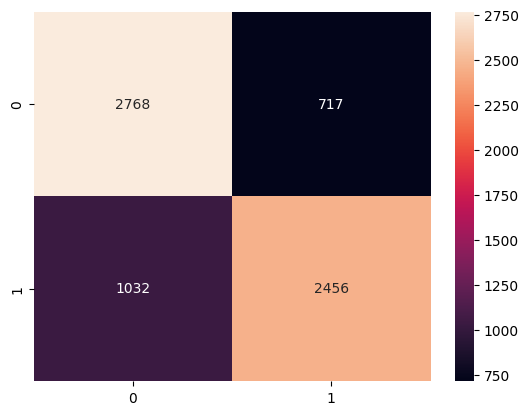

In [ ]:
model.eval()
with torch.no_grad():
    y_pred = torch.sigmoid(model(torch.from_numpy(x_test).type(torch.float32).to(device))).cpu().detach().numpy()

y_pred = (y_pred >= 0.5).astype(int).squeeze()
score = 100 * accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(score))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.show()

In [ ]:
def predict_lung_cancer(age, smoke, yellow_fingers, anxiety, peer_pressure, chronic_disease,
                        fatigue, allergies, wheezing, alcohol_consumption, coughing,
                        shortness_of_breath, swallowing_difficulty, chest_pain):
    try:
        user_input = np.array([[age, smoke, yellow_fingers, anxiety, peer_pressure, chronic_disease,
                                fatigue, allergies, wheezing, alcohol_consumption, coughing,
                                shortness_of_breath, swallowing_difficulty, chest_pain]])
        user_input_scaled = scaler.transform(user_input)
        user_input_tensor = torch.from_numpy(user_input_scaled).type(torch.float32).to(device)
        model.eval()
        with torch.no_grad():
            prediction = torch.sigmoid(model(user_input_tensor)).cpu().numpy()[0][0]
        result = "Not suffering from lung cancer" if prediction >= 0.5 else "Suffering from lung cancer"
        return f"Prediction: {result}"
    except Exception as e:
        return f"Error: {e}"

In [ ]:
inputs = [
    gr.Number(label="Age"),
    gr.Radio(choices=[1, 2], label="Do you smoke? (1=No, 2=Yes)"),
    gr.Radio(choices=[1, 2], label="Do you have yellow fingers? (1=No, 2=Yes)"),
    gr.Radio(choices=[1, 2], label="Do you have anxiety? (1=No, 2=Yes)"),
    gr.Radio(choices=[1, 2], label="Do you experience peer pressure? (1=No, 2=Yes)"),
    gr.Radio(choices=[1, 2], label="Do you have a chronic disease? (1=No, 2=Yes)"),
    gr.Radio(choices=[1, 2], label="Do you feel fatigue? (1=No, 2=Yes)"),
    gr.Radio(choices=[1, 2], label="Do you have allergies? (1=No, 2=Yes)"),
    gr.Radio(choices=[1, 2], label="Do you have wheezing? (1=No, 2=Yes)"),
    gr.Radio(choices=[1, 2], label="Do you consume alcohol? (1=No, 2=Yes)"),
    gr.Radio(choices=[1, 2], label="Do you cough frequently? (1=No, 2=Yes)"),
    gr.Radio(choices=[1, 2], label="Do you have shortness of breath? (1=No, 2=Yes)"),
    gr.Radio(choices=[1, 2], label="Do you have difficulty swallowing? (1=No, 2=Yes)"),
    gr.Radio(choices=[1, 2], label="Do you have chest pain? (1=No, 2=Yes)")
]

gr.Interface(fn=predict_lung_cancer, inputs=inputs, outputs="text", title="Lung Cancer Predictor").launch()

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9ab290e7a5bd514443.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
